# Supply Chain V3 — Fleet Overview

This notebook is an analytics layer over the completed Supply Chain V3 simulator. It connects to the existing TimescaleDB database and explores current and historical fleet telemetry.

**Important:** simulator business logic remains in `generators/supply_chain/`; this notebook only consumes persisted data.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Find the repository root whether Jupyter was launched from the repo root
# or from the notebooks directory.
cwd = Path.cwd()
repo_root = cwd if (cwd / "pyproject.toml").exists() else cwd.parent

load_dotenv(repo_root / ".env")

database_url = os.getenv("DATABASE_URL")
if not database_url:
    raise RuntimeError(
        "DATABASE_URL is not set. Copy .env.example to .env first."
    )

engine = create_engine(database_url)
print("SQLAlchemy engine configured for TimescaleDB")


SQLAlchemy engine configured for TimescaleDB


## 1. Find the latest simulation run

The simulator assigns a `run_id` to each historical or live simulation. Keeping runs explicit lets us analyze one simulation without mixing data from unrelated runs.

In [2]:
latest_run_sql = '''
SELECT
    run_id,
    generator_name,
    model_version,
    simulation_start,
    simulation_end,
    status
FROM sc_simulation_runs
ORDER BY run_id DESC
LIMIT 1;
'''

latest_run = pd.read_sql_query(latest_run_sql, engine)
latest_run


,run_id,generator_name,model_version,simulation_start,simulation_end,status
0,1,supply_chain,3.0.0,2026-08-22 18:23:46+00:00,2026-08-26 18:23:46+00:00,COMPLETED


In [3]:
if latest_run.empty:
    raise RuntimeError("No simulation runs were found in sc_simulation_runs.")

run_id = int(latest_run.loc[0, "run_id"])
print(f"Using run_id={run_id}")


Using run_id=1


## 2. Latest state of each vehicle

The grain of `sc_fleet_telemetry` is **one telemetry observation**. Here we use PostgreSQL `DISTINCT ON` to transform that into **one latest row per vehicle**.

In [4]:
latest_vehicle_sql = '''
SELECT DISTINCT ON (t.vehicle_id)
    t.vehicle_id,
    v.vehicle_reg,
    v.vehicle_type,
    t.shipment_id,
    t.time,
    t.speed_kmh,
    t.fuel_level_pct,
    t.cargo_temp_c
FROM sc_fleet_telemetry AS t
JOIN sc_vehicles AS v
    ON t.vehicle_id = v.vehicle_id
WHERE t.run_id = %s
ORDER BY t.vehicle_id, t.time DESC;
'''

latest_vehicle_state = pd.read_sql_query(
    latest_vehicle_sql,
    engine,
    params=(run_id,),
)

latest_vehicle_state


,vehicle_id,vehicle_reg,vehicle_type,shipment_id,time,speed_kmh,fuel_level_pct,cargo_temp_c
0,1,TX-7842-TR,TRUCK,13,2026-08-25 01:01:24.070302+00:00,0.0,73.43,NaN
1,2,CA-9911-RF,REEFER,19,2026-08-25 13:37:28.669604+00:00,0.0,78.67,4.0
2,3,AZ-4455-TK,TANKER,24,2026-08-24 22:59:55.507803+00:00,0.0,89.81,NaN
3,4,NM-1122-VN,VAN,23,2026-08-25 06:07:50.880174+00:00,0.0,81.17,NaN
4,5,TX-3366-TR,TRUCK,22,2026-08-25 01:49:28.857143+00:00,0.0,63.73,NaN
5,6,CA-7788-RF,REEFER,20,2026-08-25 04:37:50.897959+00:00,0.0,88.88,4.0
6,7,TX-9900-TK,TANKER,16,2026-08-25 05:18:40.809688+00:00,0.0,74.25,NaN
7,8,AZ-2233-VN,VAN,21,2026-08-24 17:07:29.255814+00:00,0.0,76.13,NaN


## 3. Basic fleet summary

This is a small descriptive summary of the latest telemetry state.

In [5]:
fleet_summary = pd.DataFrame(
    {
        "vehicles_reporting": [latest_vehicle_state["vehicle_id"].nunique()],
        "avg_speed_kmh": [latest_vehicle_state["speed_kmh"].mean()],
        "min_fuel_pct": [latest_vehicle_state["fuel_level_pct"].min()],
        "reefer_rows": [latest_vehicle_state["cargo_temp_c"].notna().sum()],
    }
)

fleet_summary


,vehicles_reporting,avg_speed_kmh,min_fuel_pct,reefer_rows
0,8,0.0,63.73,2


## 4. Fleet average speed over time

This query aggregates the raw telemetry into one-minute buckets. `time_bucket()` is a TimescaleDB function, so this cell demonstrates database-specific time-series SQL.

In [6]:
fleet_speed_sql = '''
SELECT
    time_bucket('1 minute', time) AS bucket,
    AVG(speed_kmh) AS avg_speed_kmh
FROM sc_fleet_telemetry
WHERE run_id = %s
GROUP BY bucket
ORDER BY bucket;
'''

fleet_speed = pd.read_sql_query(
    fleet_speed_sql,
    engine,
    params=(run_id,),
)

fleet_speed.head()


,bucket,avg_speed_kmh
0,2026-08-22 19:03:00+00:00,83.64
1,2026-08-22 19:13:00+00:00,83.64
2,2026-08-22 19:23:00+00:00,83.64
3,2026-08-22 19:33:00+00:00,82.82
4,2026-08-22 19:43:00+00:00,82.82


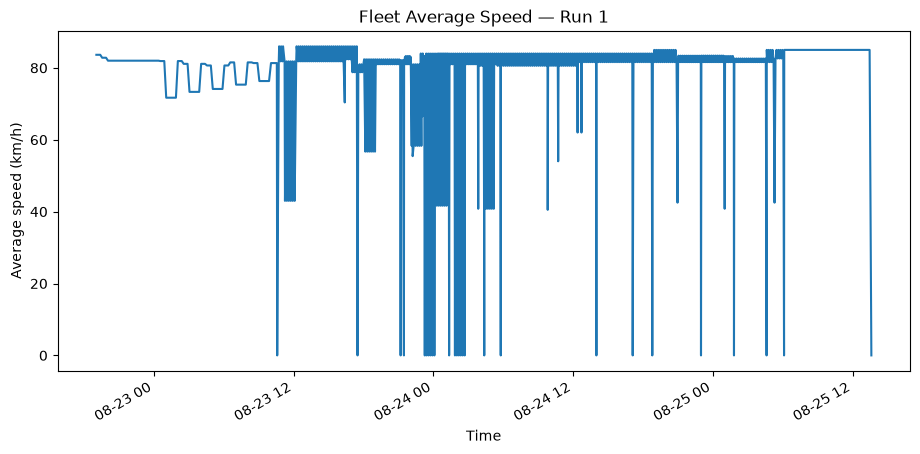

In [7]:
if not fleet_speed.empty:
    ax = fleet_speed.plot(
        x="bucket",
        y="avg_speed_kmh",
        figsize=(11, 5),
        legend=False,
        title=f"Fleet Average Speed — Run {run_id}",
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Average speed (km/h)")
    plt.show()
else:
    print("No fleet telemetry exists for this run.")


## 5. Close the database connection

Run this cell when you are finished with the notebook.

In [8]:
engine.dispose()
print("SQLAlchemy connection pool disposed")

SQLAlchemy connection pool disposed
